#**Workseet 3: Modelling the Neuron**

#**Task 1: MCP Neurons (AND & OR)**

##**And Gate**

In [11]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)

  state_neuron = []           # will hold our 0/1 predictions

  for i in range(len(X1)):
      total = X1[i] + X2[i]  # Step 1: sum the inputs
      if total >= T:          # Step 2: compare against threshold
              state_neuron.append(1)
      else:
              state_neuron.append(0)
  return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2          # AND needs BOTH inputs → sum must be 2

result_and = MCP_Neurons_AND(X1, X2, T)
print(f"AND gate  | inputs {X1} and {X2} | T={T} | output: {result_and}")


AND gate  | inputs [0, 0, 1, 1] and [0, 1, 0, 1] | T=2 | output: [0, 0, 0, 1]


##**OR Gate**

In [12]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR operation using an MCP Neuron.
    At least one input must be 1 for the output to be 1.
    We set T=1 so any non-zero sum fires the neuron.
    """
    assert len(X1) == len(X2), "Input arrays must be the same length"

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]  # Step 1: sum the inputs
        if total >= T:          # Step 2: compare against threshold
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1          # OR needs AT LEAST ONE input → sum must be ≥ 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR gate   | inputs {X1} and {X2} | T={T} | output: {result_or}")

OR gate   | inputs [0, 0, 1, 1] and [0, 1, 0, 1] | T=1 | output: [0, 1, 1, 1]


##**Task 1 – Written Questions**

###Question 1: Limitations of MCP Neurons

1. **Fixed, manual weights** – You must manually decide the threshold T. The MCP neuron cannot learn from data; weights are not adjusted automatically.
2. **Binary inputs only** – Inputs must be exactly 0 or 1. It cannot handle real-valued (continuous) inputs.
3. **No learning algorithm** – There is no mechanism to update weights based on errors, so it cannot adapt to new data.
4. **Cannot solve non-linearly separable problems** – For example, XOR cannot be solved by a single MCP neuron because the classes are not linearly separable.
5. **Equal weights** – All inputs contribute equally (weight = 1). In reality, some inputs may be more important than others.
6. **No bias term** – The decision boundary always passes through the origin; there is no flexibility to shift it.




###Question 2: Can MCP Neuron solve XOR?

**A single MCP neuron CANNOT solve XOR** because:
- If T=1 (OR), it outputs [0,1,1,1] → wrong for (1,1)
- If T=2 (AND), it outputs [0,0,0,1] → wrong for (0,1) and (1,0)
- No single threshold works for all four cases.

XOR requires **two layers** (combining AND, OR, and NOT), which is why we need more powerful models like multi-layer perceptrons.


# **TASK 2: Perceptron for 0 vs 1 Classification (MNIST)**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI and ML/mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values   # pixel values  → shape (n_samples, 784)
y = df_0_1["label"].values                  # class labels  → shape (n_samples,)

print("Feature matrix shape:", X.shape)   # (n_samples, 784)
print("Label vector shape:  ", y.shape)   # (n_samples,)

Feature matrix shape: (12665, 784)
Label vector shape:   (12665,)


##Answer the Following Question:

### Question 1: What does the shape of X represent?
X.shape = (n_samples, 784).  
- **n_samples** = number of images in the dataset.  
- **784** = 28 × 28 pixels — each image is "flattened" from a 2-D grid into one long row of pixel values.

### Question 2: What does the shape of y represent?
y.shape = (n_samples,).  
- One label per image (either 0 or 1), telling the model which digit the image shows.

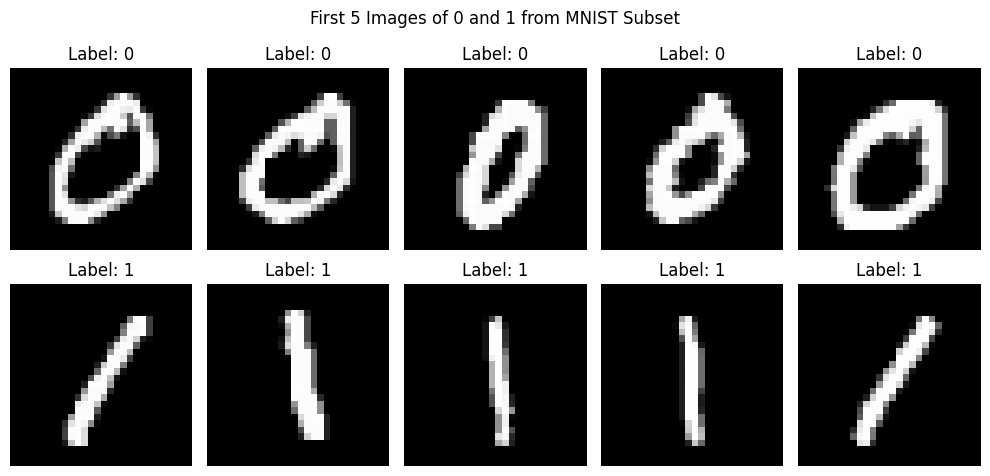

In [16]:
#Step 2: Visualise the dataset
images_0 = X[y == 0]   # all images of digit 0
images_1 = X[y == 1]   # all images of digit 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Not enough images to plot 5 examples.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

In [17]:
#Initialise weights and bias
weights       = np.zeros(X.shape[1])   # 784 weights, all starting at 0
bias          = 0
learning_rate = 0.1
epochs        = 100

print("Weights shape:", weights.shape)
print("Initial bias: ", bias)

Weights shape: (784,)
Initial bias:  0


###Question 3: What does the weights array represent?
Each of the 784 weights corresponds to one pixel in the 28×28 image.  
A weight tells the perceptron how important that pixel is for deciding between digit 0 and digit 1.  


###Question 4: Why initialize weights to zero? What effect could this have?
Starting at zero is a simple, neutral starting point no pixel is preferred over another.  
Possible effect: For a single perceptron this is fine; however in multi-layer networks, all-zero initialization causes every neuron to learn the same thing (called the "symmetry problem"). For the perceptron here it works because the update rule breaks symmetry as soon as the first misclassification occurs.

In [18]:
# Decision / Activation Function
def decision_function(X, weights, bias):
    """
    Applies the step function:
      - Compute weighted sum:  z = X · weights + bias
      - Output 1 if z >= 0, else output 0
    """
    predictions = np.dot(X, weights) + bias   # shape: (n_samples,)
    # np.where(condition, value_if_true, value_if_false)
    y_pred_all  = np.where(predictions >= 0, 1, 0)
    return y_pred_all

sample_pred = decision_function(X[:5], weights, bias)
print("Sample predictions before training:", sample_pred)

Sample predictions before training: [1 1 1 1 1]


In [19]:
# Perceptron Training Algorithm
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Trains the perceptron using the Perceptron Learning Rule.

    For each epoch:
      For each sample:
        1. Compute weighted sum  z = dot(x_i, w) + b
        2. Apply step function   y_hat = 1 if z>=0 else 0
        3. If y_hat != y_true:
             w = w + lr * (y_true - y_hat) * x_i
             b = b + lr * (y_true - y_hat)
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        correct = 0                        # count correct predictions this epoch
        converged = True                   # assume convergence unless a weight update happens

        for i in range(n_samples):
            #  forward pass
            z     = np.dot(X[i], weights) + bias   # weighted sum
            y_hat = 1 if z >= 0 else 0             # step function

            #  check prediction
            if y_hat == y[i]:
                correct += 1
            else:
                # weight update (Perceptron Rule)
                error    = y[i] - y_hat            # +1 or -1
                weights += learning_rate * error * X[i]
                bias    += learning_rate * error
                converged = False                  # weights changed → not converged yet

        accuracy = correct / n_samples * 100

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Accuracy: {accuracy:.2f}%")

        # Early stopping when fully converged
        if converged:
            print(f"\nConverged at epoch {epoch+1}!")
            break

    return weights, bias, accuracy


# Train
weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate=0.1, epochs=100)
print(f"\nFinal Training Accuracy: {accuracy:.2f}%")

Epoch  10/100 | Accuracy: 99.92%

Converged at epoch 13!

Final Training Accuracy: 100.00%


###Question 5: Purpose of `z = np.dot(X[i], weights) + bias`
This computes the **weighted sum** (also called the net input) for one image.  
`np.dot(X[i], weights)` multiplies each pixel value by its corresponding weight and sums them all up. Adding `bias` shifts the result, giving the perceptron flexibility to move its decision boundary away from the origin.

###Question 6: What happens when prediction is wrong?
When `y_hat ≠ y_true`, the error = `y_true - y_hat` (either +1 or -1).  
- **Weights update:** `w = w + lr × error × x_i` — pixels that were "loud" in the wrong direction get penalized; pixels pointing in the right direction get reinforced.  
- **Bias update:** `b = b + lr × error` — shifts the decision boundary.

###Question 7: Why is final accuracy important?
Accuracy tells us how often the perceptron classifies correctly.  
For a simple binary task like 0 vs 1 (very visually distinct digits), we expect **~99–100% accuracy** because the data is nearly linearly separable.

In [20]:
#  Visualise Misclassified Images
predictions       = np.dot(X, weights) + bias
y_pred            = np.where(predictions >= 0, 1, 0)
final_accuracy    = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred[idx]}  True:{y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images – 0 vs 1")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000 (100.00%)
All images were correctly classified!


###Question 8: What does `misclassified_idx` store?
`np.where(y_pred != y)[0]` returns the **index positions** of every image where the predicted label differs from the true label.  
It is then used to look up those images in `X` and display them in a grid, so we can visually inspect which digits confused the perceptron.

###Question 9: How to interpret "All images were correctly classified!"?
It means the perceptron found a perfect linear decision boundary that separates every 0 from every 1 in the training data — **100% training accuracy**.  
This is expected here because digits 0 and 1 are visually very different and their pixel patterns are linearly separable.

#TASK 3: Perceptron for 3 vs 5 Classification (MNIST)

In [22]:
# Load dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI and ML/mnist_3_and_5.csv")   # update path if needed

X2 = df_3_5.drop(columns=["label"]).values
y2 = df_3_5["label"].values

# Convert labels to 0 and 1  (3 → 0,  5 → 1)
# This makes the step function work the same way as Task 2
y2_binary = np.where(y2 == 3, 0, 1)

print("Feature matrix shape:", X2.shape)
print("Label vector shape:  ", y2.shape)
print("Unique original labels:", np.unique(y2))

Feature matrix shape: (2741, 784)
Label vector shape:   (2741,)
Unique original labels: [3 5]


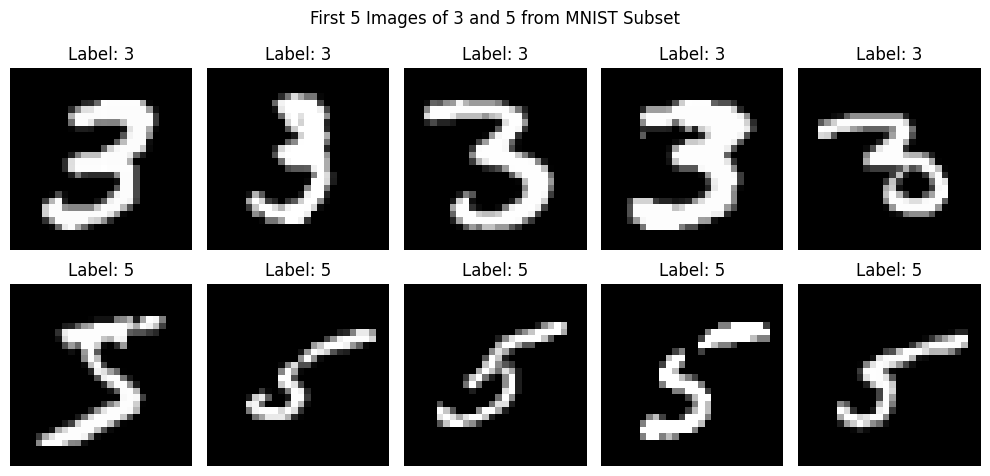

In [23]:
# Visualise
images_3 = X2[y2 == 3]
images_5 = X2[y2 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

In [24]:
#Initialise weights and bias
weights2       = np.zeros(X2.shape[1])
bias2          = 0
learning_rate2 = 0.1
epochs2        = 100

#Train
weights2, bias2, accuracy2 = train_perceptron(X2, y2_binary, weights2, bias2,
                                              learning_rate=learning_rate2,
                                              epochs=epochs2)
print(f"\nFinal Training Accuracy (3 vs 5): {accuracy2:.2f}%")

Epoch  10/100 | Accuracy: 95.66%
Epoch  20/100 | Accuracy: 96.61%
Epoch  30/100 | Accuracy: 97.26%
Epoch  40/100 | Accuracy: 97.19%
Epoch  50/100 | Accuracy: 97.88%
Epoch  60/100 | Accuracy: 97.59%
Epoch  70/100 | Accuracy: 97.92%
Epoch  80/100 | Accuracy: 97.92%
Epoch  90/100 | Accuracy: 98.43%
Epoch 100/100 | Accuracy: 98.58%

Final Training Accuracy (3 vs 5): 98.58%


Final Accuracy: 0.9869 (98.69%)


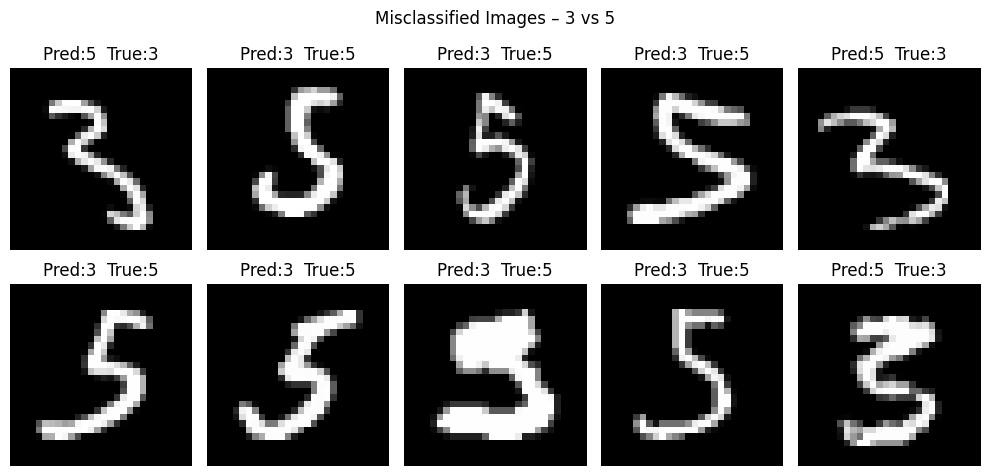

In [25]:
# Visualise Misclassified Images
predictions2    = np.dot(X2, weights2) + bias2
y_pred2         = np.where(predictions2 >= 0, 1, 0)
final_acc2      = np.mean(y_pred2 == y2_binary)
print(f"Final Accuracy: {final_acc2:.4f} ({final_acc2*100:.2f}%)")

# Convert predictions back to original labels for display
y_pred2_labels  = np.where(y_pred2 == 0, 3, 5)

misclassified2  = np.where(y_pred2 != y2_binary)[0]

if len(misclassified2) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified2[:10]):
        ax.imshow(X2[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred2_labels[idx]}  True:{y2[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images – 3 vs 5")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

##Task 3 – Conclusion

Classifying **3 vs 5** is harder than **0 vs 1** because:
- The digits share many similar curves and strokes they are more **visually similar**.
- The pixel patterns are **not perfectly linearly separable**, so the perceptron cannot find a single straight decision boundary that works for every sample.

As a result, you will likely see:
- **Lower accuracy** (perhaps 85–95% instead of ~100%).
- **More misclassified images**  ambiguous handwriting causes the perceptron to confuse the two digits.

**This demonstrates the key limitation of the perceptron:** it fails on problems that are not linearly separable. To solve these, we need **multi-layer neural networks** (deep learning).